# Import:

In [1]:
from Normalization import split
from Models import baselines, gears_predict
from Metrics import performance_metrics

import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import os
import pickle
from gears import utils, pertdata
from tqdm import tqdm

/storage/mi/sommereg03/vsp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
grn_file = "KeggoRo_noG"
names = ["Norman19","Replogle22"]
models = ["experimental","pGRiNS"]#,"mixed"] # Mixed will have for each pert i% cells of pGRiNS and (1-i)% cells of exp.
ccs = [None]

# Prepare Data:

In [3]:
data = {}
for name in names:
    data[name] = {}
    for model in models:
        data[name][model] = {}
    data[name]["experimental"]["adata"] = sc.read_h5ad(f"../../Data/Experimental/{name}/perturb_norm_subset_{grn_file}.h5ad")
    if data[name]["experimental"]["adata"].X is None:
        data[name]["experimental"]["adata"].X = data[name]["experimental"]["adata"].layers["log1p"].copy()

In [4]:

pgrins_full = sc.read_h5ad(f"../../Data/Projects/{grn_file}/001/perturb_norm_full.h5ad")
for name in names:
    data[name]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["PertNum"].isin(data[name]["experimental"]["adata"].obs["PertNum"]),sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]
    data[name]["pGRiNS"]["adata"].obs["cell_line"] = f"syn_{list(data[name]["experimental"]["adata"].obs["cell_line"])[0]}"
    data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][:,sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(data[name]["pGRiNS"]["adata"].var_names)))]


## Remove perturbations not in GO graph:

In [5]:
def get_bad_perts(norm_data,name) -> list[str]:
    """
    Retrieves a list of perturbations from the dataset that are not found in the GO graph of gears and must therefore be skipped.

    Parameters:
    -----------
    norm_data : anndata
        An anndata object containing the normalized data.
    filename : str
        The name of the dataset.
    
    Returns:
    --------
    not_in_go_pert : list[str]
        A list of perturbation names that are not in the GO graph.
    """

    # For GEARS:
    os.makedirs(f"../../Data/Experimental/{name}/experimental",exist_ok=True)
    pert_data = pertdata.PertData(f"../../Data/Experimental/{name}/experimental")
    pert_data.set_pert_genes()
    with open(f"../../Data/Experimental/{name}/experimental/gene2go_all.pkl", 'rb') as f:
        gene2go = pickle.load(f)
    with open(f"../../Data/Experimental/{name}/experimental/essential_all_data_pert_genes.pkl", 'rb') as f:
        essential_genes = pickle.load(f)
    gene2go = {g: gene2go[g] for g in essential_genes if g in gene2go}

    pert_names = np.unique(list(gene2go.keys()))

    not_in_go_pert = np.array(norm_data.obs[norm_data.obs.condition.apply(lambda x:not utils.filter_pert_in_go(x,pert_names))].condition.unique())
    return not_in_go_pert

In [6]:
for name in names:
    bad_perts = get_bad_perts(data[name]["experimental"]["adata"],name) # Get perturbations that need to be skipped
    for model in models:
        data[name][model]["pert_indices"] = (split.ctrl_pert_split_dataset(data[name][model]["adata"],bad_perts))

Found local copy...
Found local copy...
Found local copy...
Found local copy...


In [7]:
for name in names:
    if not os.path.exists(f"../../Data/Projects/{grn_file}/001/perturb_norm_subset_{name}.h5ad"):
        data[name]["pGRiNS"]["adata"].write_h5ad(f"../../Data/Projects/{grn_file}/001/perturb_norm_subset_{name}.h5ad")

## Create train/test split:

In [8]:
no_iterations = 5
for name in names:
    for it in range(no_iterations):
        os.makedirs(f"../../Data/Experimental/{name}/Splits",exist_ok=True)
    ctrl_i_vec, pert_i_dict = data[name]["experimental"]["pert_indices"]
    if False in [os.path.isfile(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle") for it in range(no_iterations)]: # If one cv_it model has not been generated for the current file
        print("Creating splits")
        splits = split.cross_validate_split_blockwise(data[name]["experimental"]["adata"], pert_i_dict, name, need_val=False, no_iterations=no_iterations) # Possible that data_loader in GEARS doesnt work if need_val=False
        

# Train Models:
Done in separate file(s)

## Make predictions:

In [9]:
# GEARS:
def do_gears_pred(names,models,ccs,no_iterations=5):
    for name in names:
        for model in models:
            for cc in ccs:
                print(f"{name}, {model} ({cc}):")
                for it in tqdm(range(no_iterations)):
                    splits = pickle.load(open(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle",'rb'))
                    train_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["train"]])
                    val_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["val"]])
                    test_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["test"]])
                    try:
                        gears_dict = gears_predict.predict_gears(it,test_perts,name,model,cc)
                    except:
                        if cc == None:
                            series = " "
                        else:
                            series = f" {cc} "
                        print(f"No GEARS model trained for iteration {it} of {name}/{model}. Please execute\nnohup python3 -u train_gears_parallel.py {name} {model} {grn_file} {no_iterations}{series}> ../../Logs/GEARS_{name}_{model}_out.log 2>&1 &\non the cluster.")
                        

# Evaluate Models:

In [44]:
# Can handle two cases: (1) ccs = [None] and models = ["experimental","pGRiNS"]; (2) ccs : list[int] and models = ["pGRiNS_series"]
def eval_datasets(names,models,ccs,no_iterations=5):
    # Split perturbations into train/validate/test datasets:
    all_names = []
    for name in names:
        all_models = []
        for model in models:
            if model == "pGRiNS_series":
                data_model = "pGRiNS"
            else:
                data_model = model
            ctrl_i_vec, pert_i_dict = data[name][data_model]["pert_indices"]
            all_iterations = []
            deg_all_it = []
            for it in tqdm(range(no_iterations)):
                #print(f"\t({it+1}/{no_iterations})")

                splits = pickle.load(open(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle",'rb'))
                train_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["train"]])
                val_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["val"]])
                test_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["test"]])
                
                td_index_dict, gt_index_dict = baselines.td_gt_split(pert_i_dict,test_perts) # TD/GT split
                
                # Generate baselines:
                #print("Technical Duplicate")
                mu_td_dict, mu_gt_dict = baselines.technical_duplicate(data[name][data_model]["adata"],td_index_dict,gt_index_dict) # Positive control
                #print("Control Baseline")
                mu_unperturbed = baselines.control_baseline(data[name][data_model]["adata"],ctrl_i_vec) # Negative control
                #print("Informed Model")
                #informed_dict = baselines.informed_model(data[name]["experimental"]["adata"],train_perts=train_perts,test_perts=test_perts,pert_i_dict=pert_i_dict,control_baseline=mu_unperturbed)
                #print("Mean Baseline")
                mu_all = baselines.mean_baseline(data[name][data_model]["adata"],pert_i_dict,train_perts) # Naive model
                #print("Interpolated Duplicate")
                id_dict = baselines.interpolated_duplicate(data[name][data_model]["adata"],mu_td_dict,mu_all,td_index_dict) # Positive control
                
                # Predict using the models:
                #print("GEARS")
                try:
                    if model == "pGRiNS_series":
                        gears_dicts = [gears_predict.predict_gears(it,test_perts,name,model,cc) for cc in ccs]
                        model_list = [*gears_dicts]
                    else:
                        gears_dicts = [gears_predict.predict_gears(it,test_perts,name,model,None) for model in models]
                        model_list = [mu_unperturbed,mu_all,mu_td_dict,id_dict,*gears_dicts]
                except:
                    "No GEARS model found. Skipping iteration."
                    continue
                
                # Compute simple metrics (shape: model x metric x test_pert):
                metric_matrix = performance_metrics.compute_metrics_all(mu_gt_dict, model_list, mu_unperturbed)

                # Compute weighted metrics:
                weight_dict = performance_metrics.get_weights(data[name][data_model]["adata"],mu_gt_dict,td_index_dict)
                weight_metric_matrix = performance_metrics.compute_metrics_all(mu_gt_dict, model_list, mu_all,weight_dict = weight_dict)

                all_iterations.append(np.concatenate([metric_matrix,weight_metric_matrix],axis=1))
            #print(len(all_iterations),all_iterations[0].shape,all_iterations[1].shape,all_iterations[2].shape,all_iterations[3].shape,all_iterations[4].shape)
            all_models.append(np.concatenate(all_iterations,axis=-1))#.append(np.dstack(all_iterations)) # each entry in all_models has the shape model x metric x pert
        all_names.append(np.stack(all_models))
    
    # Change order from dataset x model x ... to model x dataset x ...
    all_names_ordered = []
    for j in range(len(models)):
        model_list = []
        for i in range(len(all_names)):
            model_list.append(all_names[i][j])
        all_names_ordered.append(model_list)

    return all_names_ordered

In [11]:
import sys
sys.path.append("..")
import plotting_funs
prop_cycle = plotting_funs.set_mpl_attributes()

In [102]:
def violin_plot(model_data,model_list,model_idx,metric_list,metric_idx,suptitle,filename,colors=[],no_rows=2,no_cols=2):
    global prop_cycle, names
    models_used = [model_list[i] for i in range(len(model_list)) if i in model_idx]
    for i, name in zip(range(len(names)),names):
        name_data = model_data[i]
        fig, axs = plt.subplots(no_rows,no_cols,figsize=(4.5*no_cols,6*no_rows))
        for m,j in zip(metric_idx,range(len(metric_idx))):
            if no_rows == 1:
                if no_cols == 1:
                    ax = axs
                else:
                    ax = axs[j%no_cols]
            else:
                if no_cols == 1:
                    ax = axs[j%no_rows]
                else:
                    ax = axs[int(np.floor(j/no_rows)),j%no_cols]
            if m==-1: # Training MSEs:
                if name == "Norman19":
                    metric_data = [[0.1285, 0.0535, 0.1035, 0.1038, 0.1032],[0.1029, 0.1048, 0.0816, 0.1044, 0.0986]]
                else:
                    metric_data = [[0.1042, 0.0877, 0.1135, 0.1003, 0.1038],[0.0757, 0.0801, 0.0851, 0.0797, 0.0780]]
                ax.set_title("Test Top 20 DE MSE of\nbest performing model during training")
                no_dots = 5
            else:
                metric_data = [np.asarray(name_data[k,m,:]).squeeze() for k in model_idx]
                ax.set_title(metric_list[m])
                no_dots = name_data.shape[-1]
            violin_parts = ax.violinplot(metric_data,showmedians=True)
            colors_models = []
            for k, pc in zip(range(len(violin_parts["bodies"])),violin_parts["bodies"]):
                if models_used[k%5] == "GEARS":
                    if name == "Norman19":
                        pc.set_color(prop_cycle[0])
                        colors_models.append(prop_cycle[0])
                    elif name == "Replogle22":
                        pc.set_color(prop_cycle[1])
                        colors_models.append(prop_cycle[1])
                elif "pGRiNS" in models_used[k%5]:
                    pc.set_color(prop_cycle[2])
                    colors_models.append(prop_cycle[2])
                else:
                    pc.set_color("grey")
                #print(pc)
            violin_parts["cmaxes"].set_colors(colors+colors_models)
            violin_parts["cmins"].set_colors(colors+colors_models)
            violin_parts["cbars"].set_colors(colors+colors_models)
            violin_parts["cmedians"].set_colors(colors+colors_models)
            """
            bp = ax.boxplot(metric_data,patch_artist=True)
            for element in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
                for m, model in zip(range(len(models_used)),models_used):
                    if model == "GEARS":
                        if name == "Norman19":
                            plt.setp(bp[element][m], color=prop_cycle[0])
                        elif name == "Replogle22":
                            plt.setp(bp[element][m], color=prop_cycle[1])
                    elif model == "GEARS_pGRiNS":
                        plt.setp(bp[element][m], color=prop_cycle[2])
                    else:
                        plt.setp(bp[element][m], color="grey")
            
            for patch in bp['boxes']:
                patch.set(alpha=0)
            """
            xs = [np.random.normal(k+1,0.1,no_dots) for k in range(len(model_idx))]
            s=8
            a=0.4
            for model, x, y in zip(models_used, xs, metric_data):
                if model == "GEARS":
                    if name == "Norman19":
                        ax.scatter(x,y,alpha=a,s=s,c=prop_cycle[0])
                    elif name == "Replogle22":
                        ax.scatter(x,y,alpha=a,s=s,c=prop_cycle[1])
                elif "pGRiNS" in model:
                    ax.scatter(x,y,alpha=a,s=s,c=prop_cycle[2])
                else:
                    ax.scatter(x,y,alpha=a,s=s,c="grey")
            if "series" in models_used[0]:
                ticknames = [m.split("series")[1] for m in models_used]
            else:
                ticknames = models_used
            if ax.get_ylim()[0]<0.2:
                ax.hlines(0,0,len(model_idx)+1,lw=1,linestyles="dotted",colors="black")
            if "↑" in metric_list[m]:
                ax.hlines(1,0,len(model_idx)+1,lw=1,linestyles="dotted",colors="black")
        for col in range(no_cols):
            if no_rows == 1 and no_cols == 1:
                ax = axs
            elif no_rows == 1 and no_cols != 1:
                ax = axs[col]
            elif no_rows != 1 and no_cols == 1:
                ax = axs[-1]
            else:
                ax = axs[-1,col]
            ax.set_xticks(range(1,1+len(ticknames)),ticknames,rotation=45,ha="right")
            ax.tick_params(which='minor', length=0)
        ax.set_xticks(range(1,1+len(ticknames)),ticknames,rotation=45,ha="right")
        ax.tick_params(which='minor', length=0)
        plt.suptitle(f"{suptitle}\n\n{name}")
        plt.tight_layout()
        plt.savefig(f"Results/Figures/{name}_{filename}.png")
        plt.show()

model_list = ["Control", "Mean Baseline", "Tech. Duplicate", "Interp. Duplicate", "GEARS","GEARS_pGRiNS"]
metric_list = ["MSE (↓)","Pearson (↑)","Pearson Delta (↑)","Weighted MSE (↓)","Weighted Delta R2 (↑)"]
    

In [37]:
# If a submodule is changed, it needs to be reloaded
import importlib
importlib.reload(split)
importlib.reload(baselines)
importlib.reload(performance_metrics)
importlib.reload(gears_predict)

<module 'Models.gears_predict' from '/home/mi/sommereg03/bsc_thesis_pGRiNS/Analysis/ml_eval/Models/gears_predict.py'>

# Analysis comparing pGRiNS & experimental:

In [55]:
do_gears_pred(names,models,ccs)
all_names = eval_datasets(names,models,ccs)

Norman19, experimental (None):


100%|██████████| 5/5 [00:00<00:00, 747.30it/s]


Norman19, pGRiNS (None):


100%|██████████| 5/5 [00:00<00:00, 1031.20it/s]


Replogle22, experimental (None):


100%|██████████| 5/5 [00:00<00:00, 529.36it/s]


Replogle22, pGRiNS (None):


100%|██████████| 5/5 [01:15<00:00, 15.00s/it]


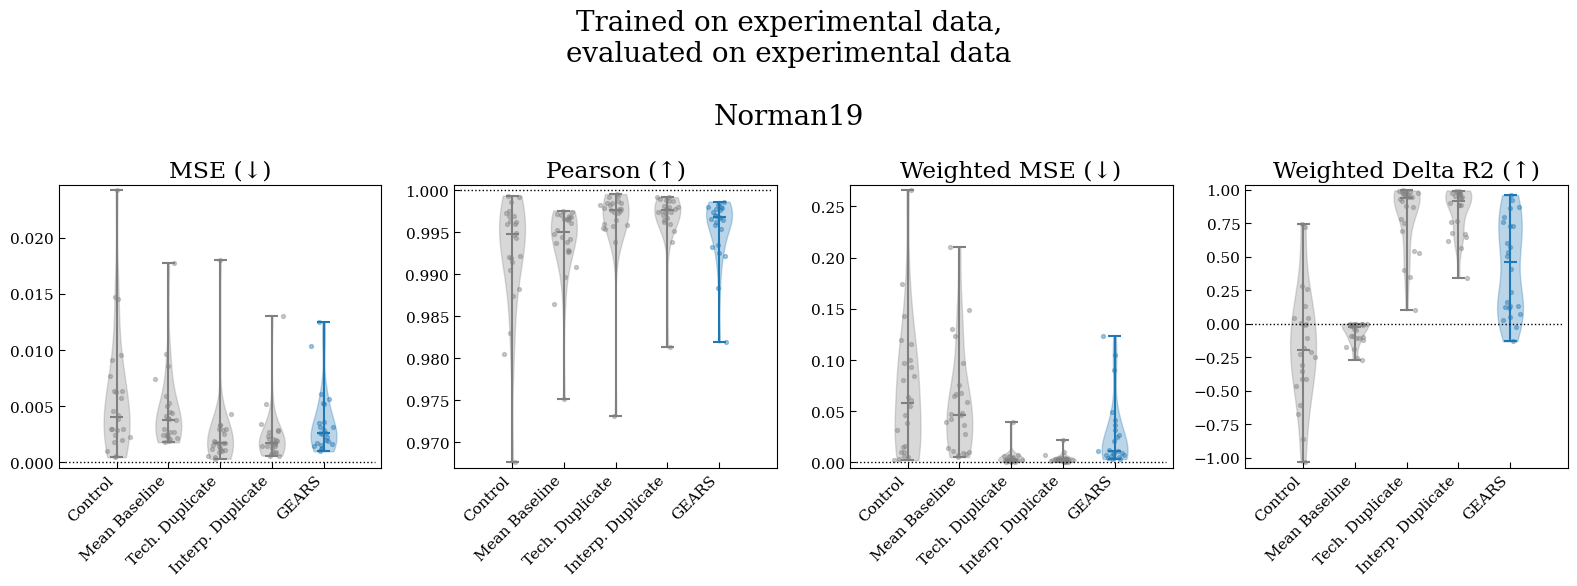

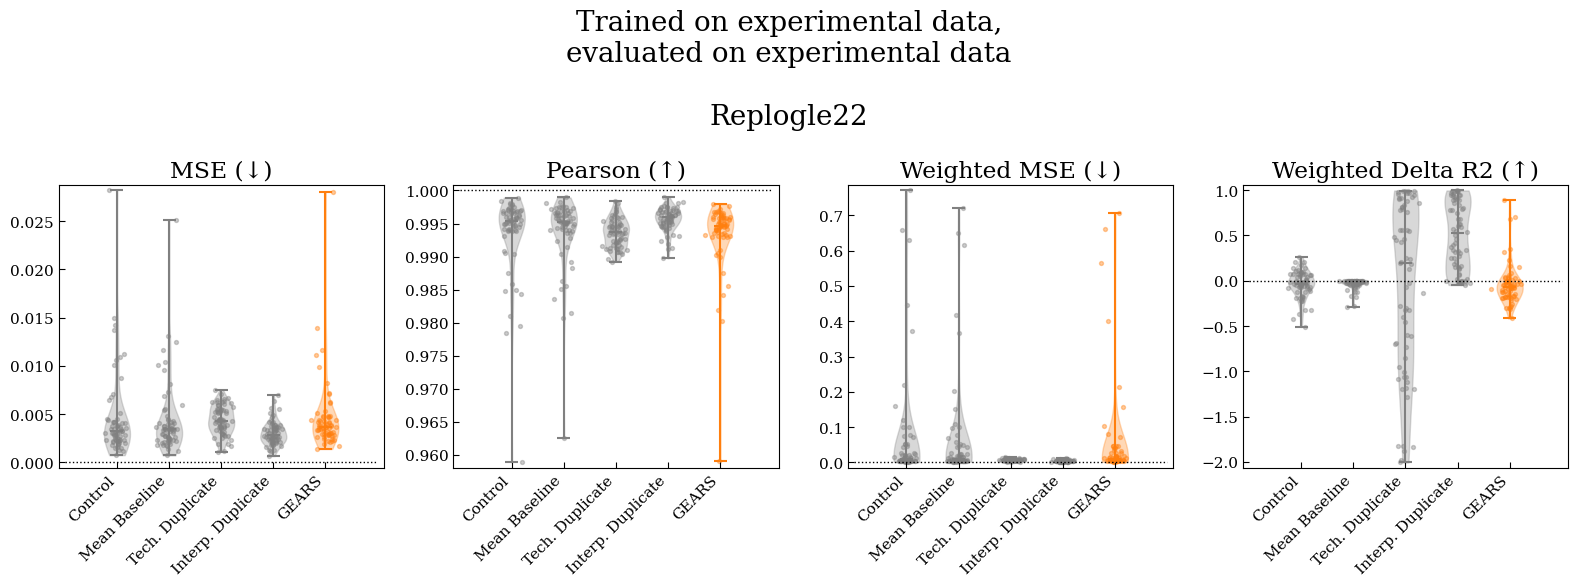

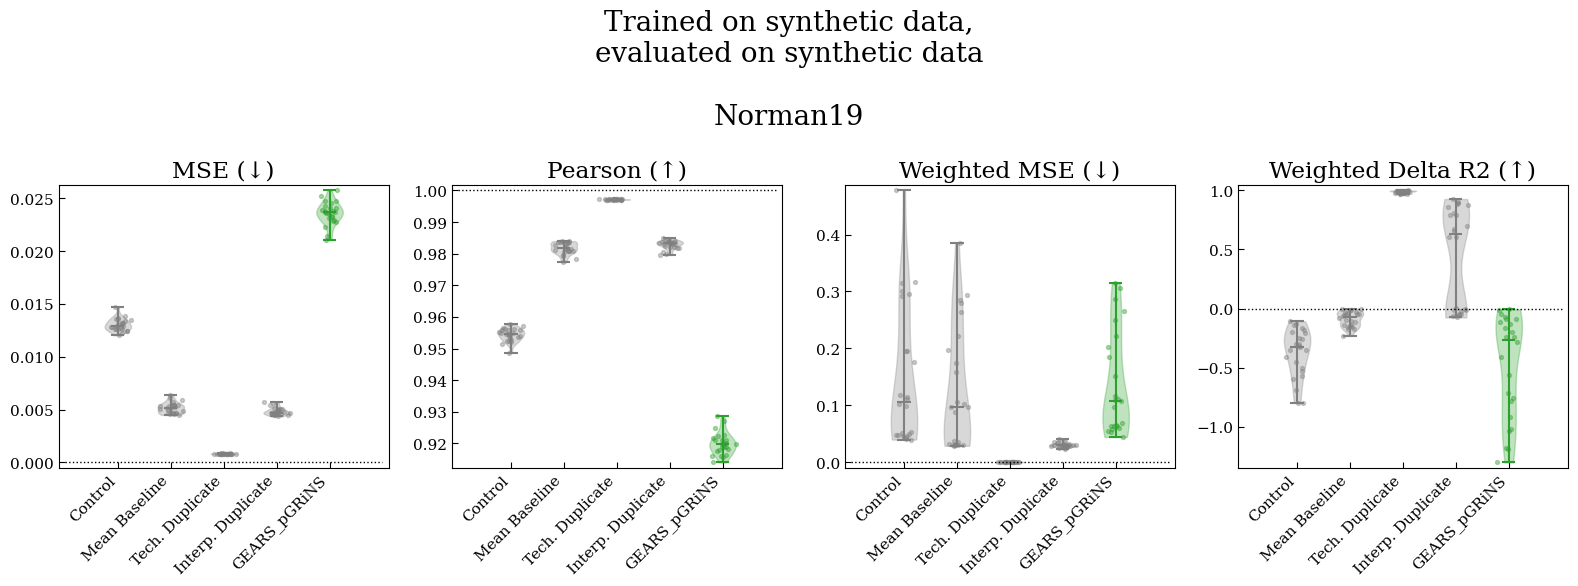

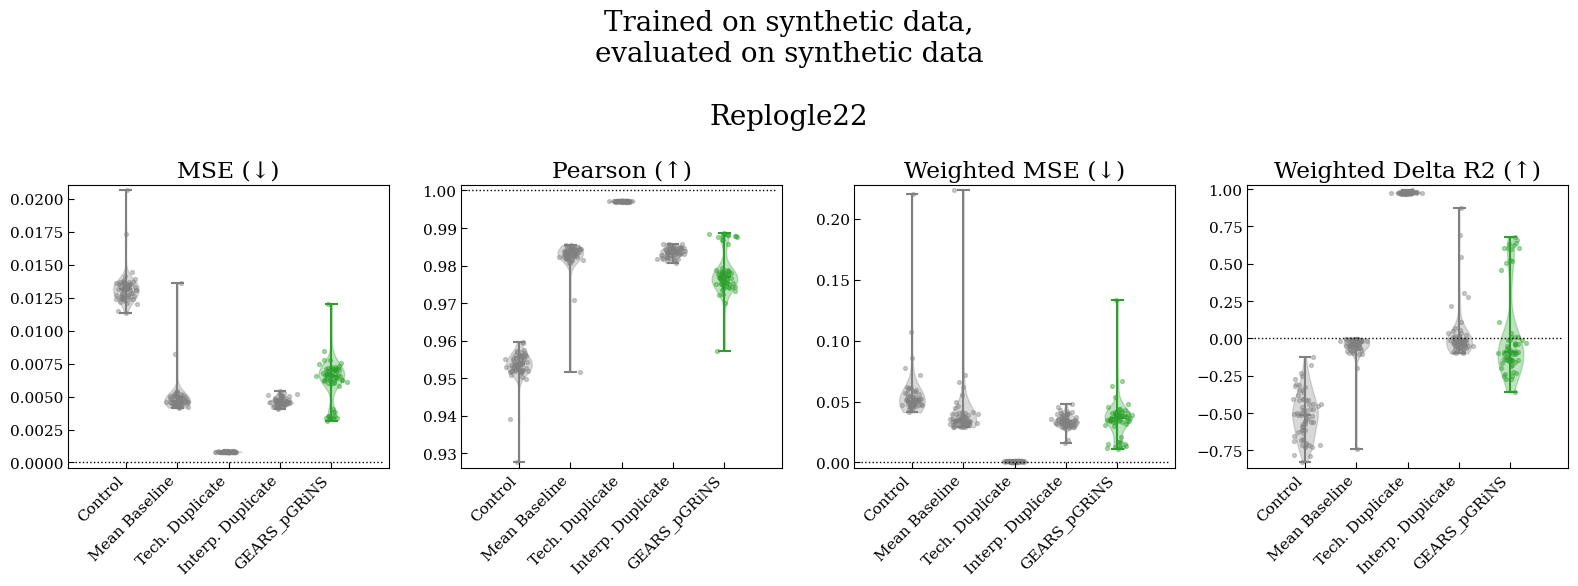

In [88]:
baseline_colors = ["grey"]*4

model_idx = [0,1,2,3,4]
metric_idx = [0,1,3,4]
suptitle = "Trained on experimental data,\nevaluated on experimental data"
filename = "GEARS_exp_exp"
violin_plot(all_names[0],model_list,model_idx,metric_list,metric_idx,suptitle,filename,baseline_colors,1,4)

model_idx = [0,1,2,3,5]
metric_idx = [0,1,3,4]
suptitle = "Trained on synthetic data,\nevaluated on synthetic data"
filename = "GEARS_syn_syn"
violin_plot(all_names[1],model_list,model_idx,metric_list,metric_idx,suptitle,filename,baseline_colors,1,4)

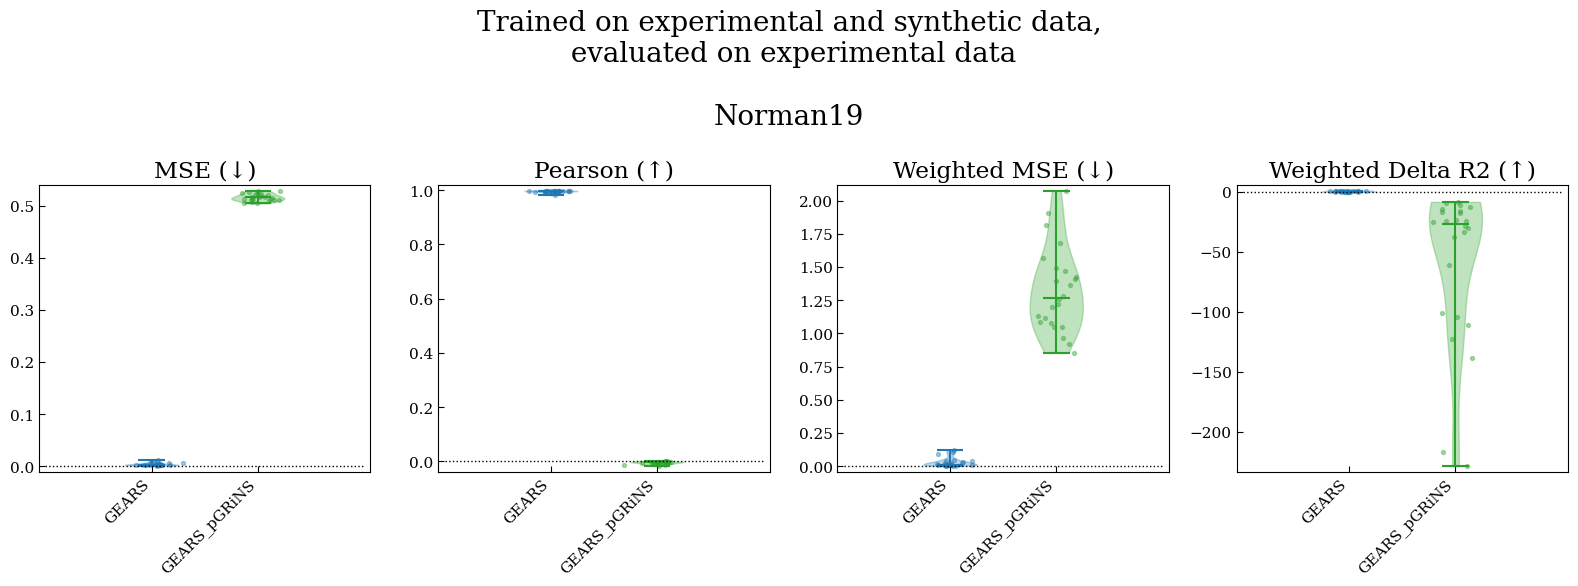

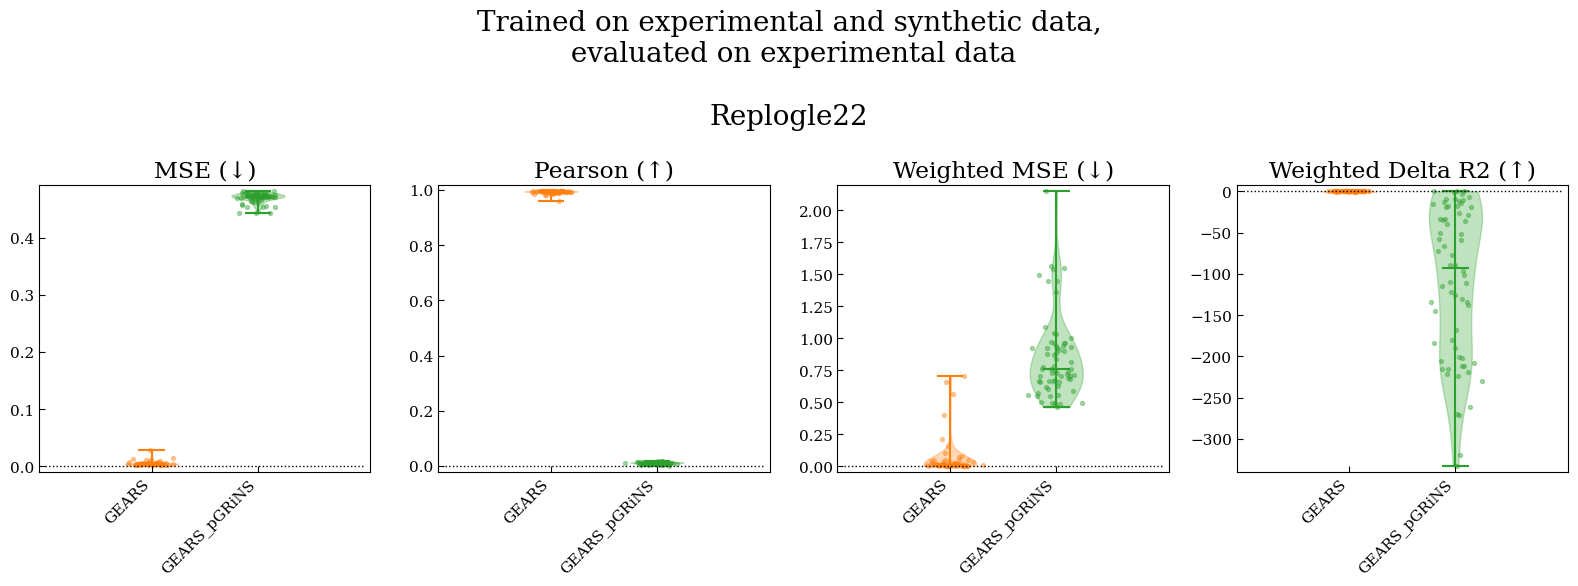

In [90]:
model_idx = [4,5]
metric_idx = [0,1,3,4]#+[-1]
filename = "GEARS_syn_exp"
suptitle = "Trained on experimental and synthetic data,\n evaluated on experimental data"
violin_plot(all_names[0],model_list,model_idx,metric_list,metric_idx,suptitle,filename,[],1,4)

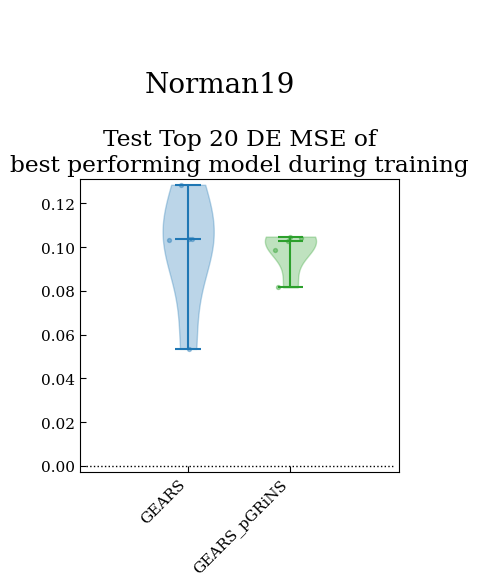

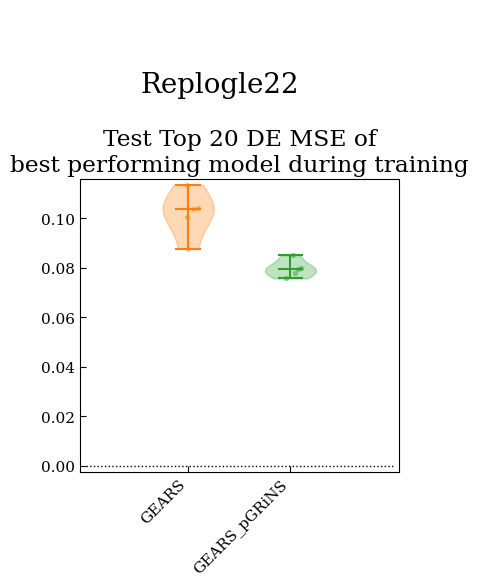

In [37]:
model_idx = [4,5]
metric_idx = [-1]
filename = "GEARS_syn_exp"
suptitle = ""#Comparison of GEARS trained on experimental and synthetic data\nusing evaluated on experimental data"
violin_plot(all_names[0],model_list,model_idx,metric_list,metric_idx,suptitle,filename,[],1,1)

In [ ]:
train_mses = [
    [[0.1285, 0.0535, 0.1035, 0.1038, 0.1032],[0.1029, 0.1048, 0.0816, 0.1044, 0.0986]],
    [[0.1042, 0.0877, 0.1135, 0.1003, 0.1038],[0.0757, 0.0801, 0.0851, 0.0797, 0.0780]]
    ]
for i in range(2):
    print(f"{names[i]}: [exp,pGRiNS]: {[(np.round(np.mean(x),5),np.round(np.var(x),5)) for x in train_mses[i]]}")

Norman19: [exp,pGRiNS]: [(np.float64(0.0985), np.float64(0.0006)), (np.float64(0.09846), np.float64(8e-05))]
Replogle22: [exp,pGRiNS]: [(np.float64(0.1019), np.float64(7e-05)), (np.float64(0.07972), np.float64(1e-05))]


# Analysis of pGRiNS depending on number of cells:

In [91]:
ccs = [5,10,25,50,75,100,250,500,1000]
models = ["pGRiNS_series"]

In [14]:
for name in names:
    os.system("ln -s ../pGRiNS/Models/ ../../Data/Experimental/"+name+"/pGRiNS_series/Models_"+str(ccs[-1]))

ln: die symbolische Verknüpfung '../../Data/Experimental/Norman19/pGRiNS_series/Models_1000/Models' konnte nicht angelegt werden: Die Datei existiert bereits
ln: die symbolische Verknüpfung '../../Data/Experimental/Replogle22/pGRiNS_series/Models_1000/Models' konnte nicht angelegt werden: Die Datei existiert bereits


In [92]:
do_gears_pred(names,models,ccs)

Norman19, pGRiNS_series (5):


100%|██████████| 5/5 [00:00<00:00, 389.46it/s]


Norman19, pGRiNS_series (10):


100%|██████████| 5/5 [00:00<00:00, 555.61it/s]


Norman19, pGRiNS_series (25):


...

100%|██████████| 5/5 [00:00<00:00, 516.62it/s]


Replogle22, pGRiNS_series (500):


100%|██████████| 5/5 [00:00<00:00, 517.79it/s]


Replogle22, pGRiNS_series (1000):


100%|██████████| 5/5 [00:00<00:00, 550.33it/s]


In [93]:
all_names = eval_datasets(names,models,ccs)

100%|██████████| 5/5 [01:16<00:00, 15.23s/it]


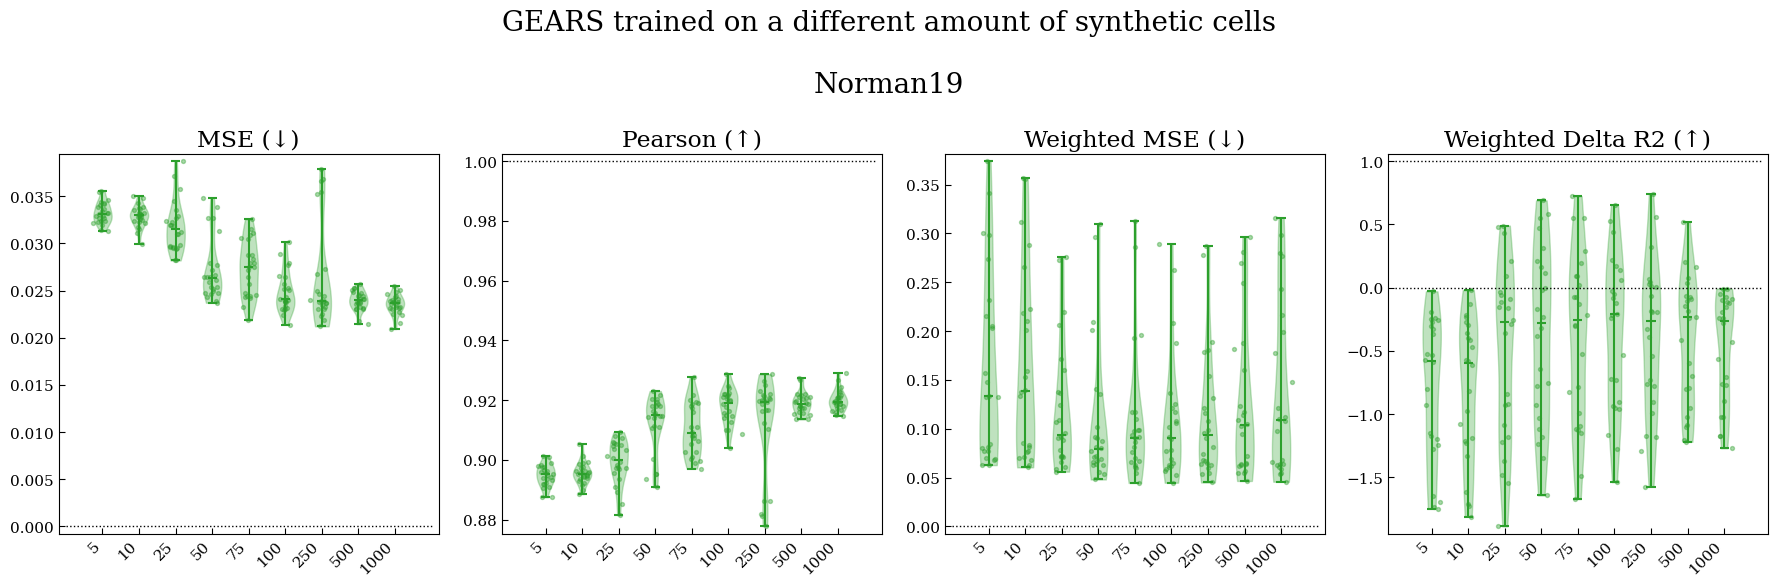

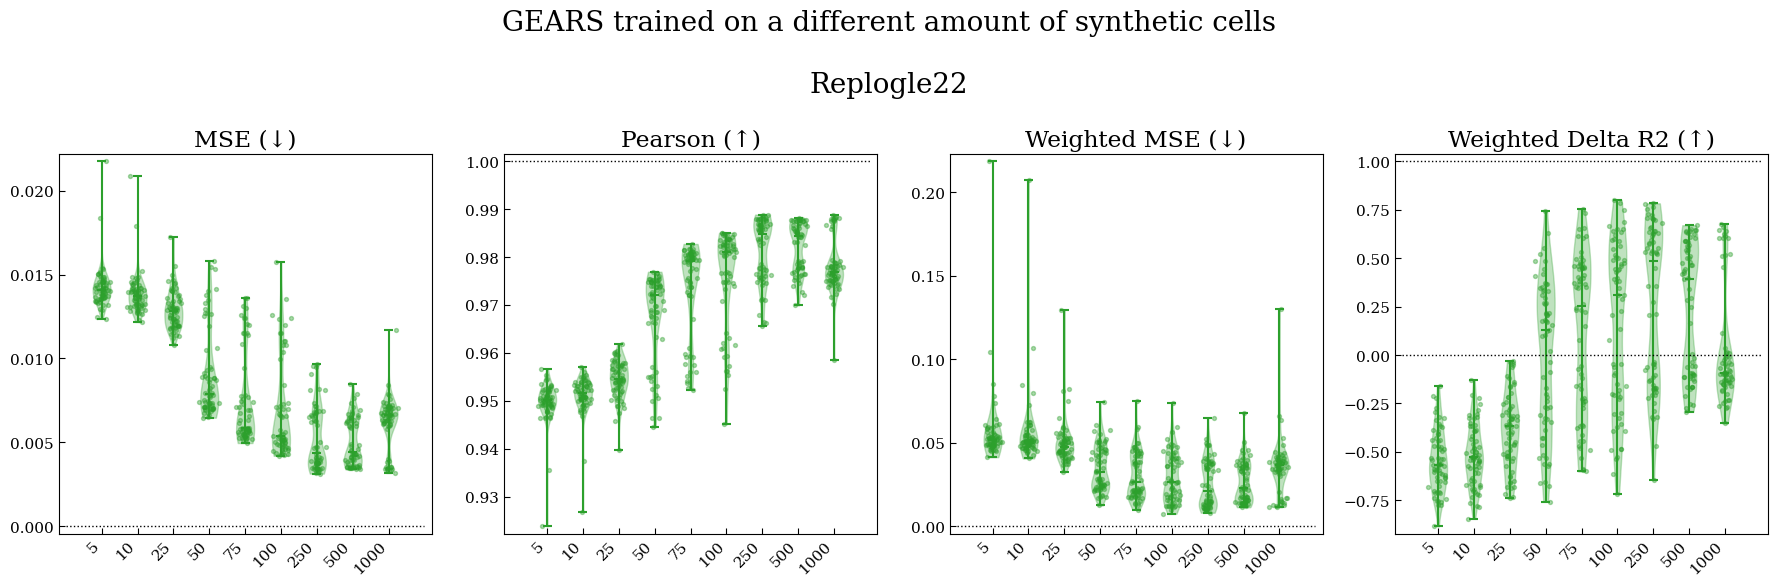

In [103]:
model_list = [f"pGRiNS_series{cc}" for cc in ccs]
model_idx = list(range(len(model_list)))
metric_idx = [0,1,3,4]
suptitle = "GEARS trained on a different amount of synthetic cells"
filename = "pGRiNS_series"
violin_plot(all_names[0],model_list,model_idx,metric_list,metric_idx,suptitle,filename,[],1,4)